CLASSIC HW only: (12047, 10)
LPJ-GUESS HW only: (12149, 10)


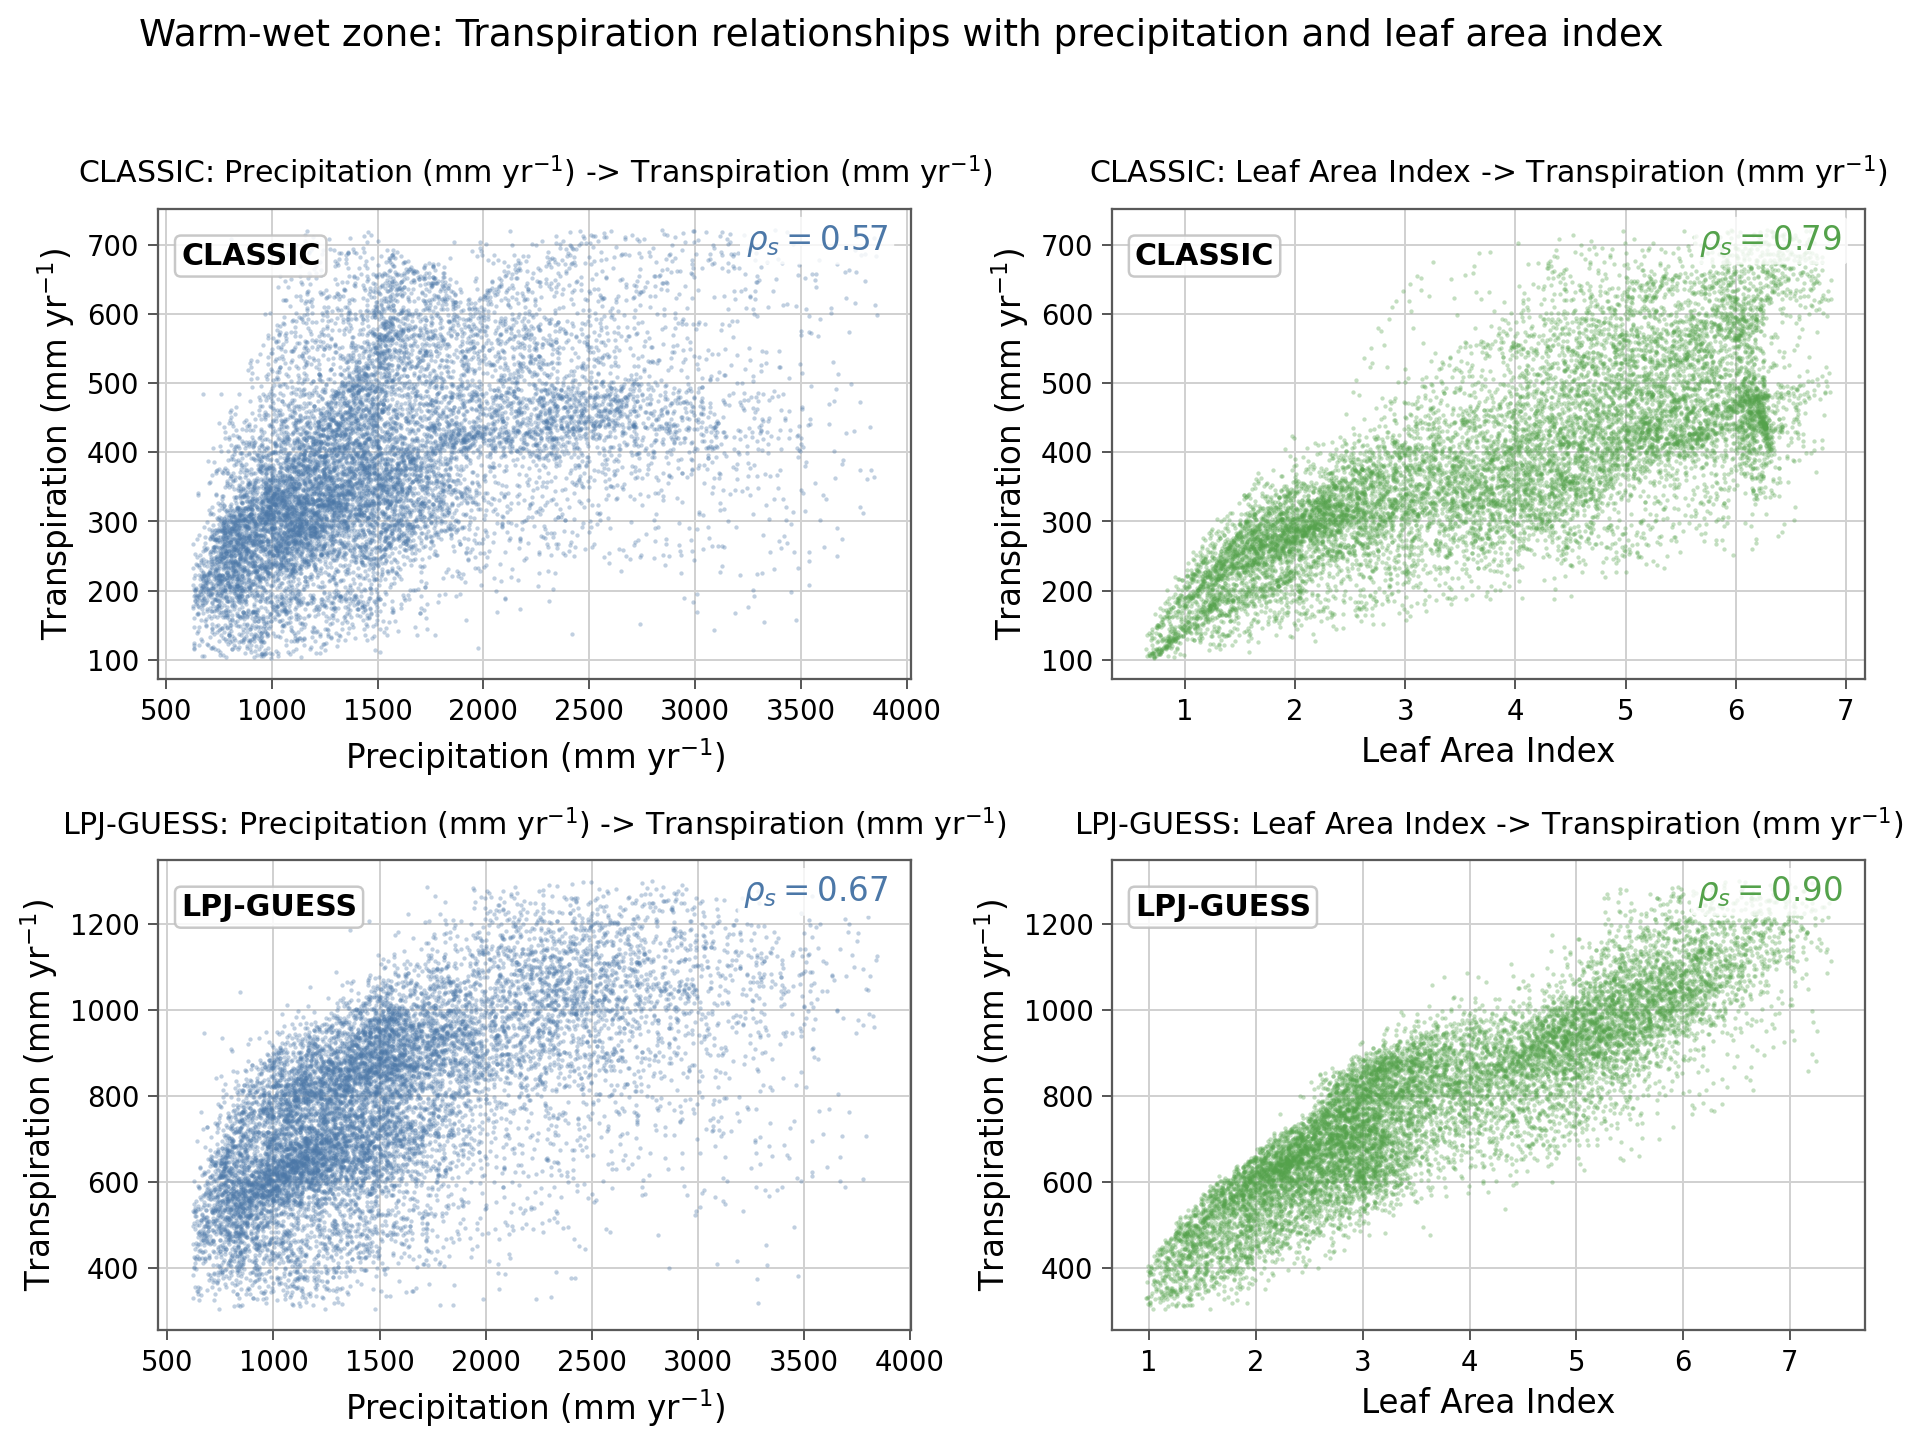

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr

# =========================
# 1. 读取数据
# =========================
data_dir = Path("./preprocessed/preprocessed_with_zones")

classic_df = pd.read_csv(data_dir / "classic_with_climate_zones_filtered_30yr_mean.csv")
lpj_df = pd.read_csv(data_dir / "lpj_guess_with_climate_zones_filtered_30yr_mean.csv")

# 只保留 warm-wet 区域 HW
classic_df = classic_df[classic_df["climate_zone"] == "HW"].copy()
lpj_df = lpj_df[lpj_df["climate_zone"] == "HW"].copy()

print("CLASSIC HW only:", classic_df.shape)
print("LPJ-GUESS HW only:", lpj_df.shape)

# =========================
# 2. 变量映射
# =========================
var_map = {
    "P": "precipitation",
    "LAI": "lai",
    "ET": "evapotrans",
    "T": "tran",
    "E_veg": "evspsblveg",
    "E_soil": "evspsblsoi"
}

# 图上显示用的全称和单位
axis_label_map = {
    "P": "Precipitation (mm yr$^{-1}$)",
    "LAI": "Leaf Area Index",
    "T": "Transpiration (mm yr$^{-1}$)"
}

# =========================
# 3. 分箱中位数函数
# =========================
def compute_binned_medians(x, y, n_bins=10):
    x = np.asarray(x)
    y = np.asarray(y)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) == 0:
        return np.array([]), np.array([])

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    idx_groups = np.array_split(np.arange(len(x_sorted)), n_bins)

    x_med, y_med = [], []
    for idx in idx_groups:
        if len(idx) == 0:
            continue

        x_med.append(np.median(x_sorted[idx]))
        y_med.append(np.median(y_sorted[idx]))

    return np.array(x_med), np.array(y_med)

# =========================
# 4. 画图函数：只看 HW，且只看 T
# =========================
def plot_hw_t_p_lai_combined(
    classic_df,
    lpj_df,
    var_map,
    axis_label_map,
    p_color="#4C78A8",
    lai_color="#54A24B",
    sample_size=30000,
    n_bins=10,
    point_size=3,
    point_alpha=0.35
):
    fig, axes = plt.subplots(
        2, 2,
        figsize=(11, 8.5),
        dpi=180,
        sharex=False,
        sharey=False
    )

    model_specs = [
        (classic_df, "CLASSIC"),
        (lpj_df, "LPJ-GUESS")
    ]

    predictor_specs = [
        ("P", p_color),
        ("LAI", lai_color)
    ]

    y_label = "T"
    y_col = var_map[y_label]

    for row, (df, model_name) in enumerate(model_specs):
        for col, (x_label, line_color) in enumerate(predictor_specs):
            ax = axes[row, col]

            x_col = var_map[x_label]
            sub = df[[x_col, y_col]].dropna().copy()

            if len(sub) > 0:
                rho, _ = spearmanr(sub[x_col].values, sub[y_col].values)

                # 散点抽样
                if len(sub) > sample_size:
                    sub_plot = sub.sample(sample_size, random_state=42)
                else:
                    sub_plot = sub

                ax.scatter(
                    sub_plot[x_col].values,
                    sub_plot[y_col].values,
                    s=point_size,
                    alpha=point_alpha,
                    color=line_color,
                    linewidths=0,
                    zorder=2
                )

                # 分箱中位数线
                x_med, y_med = compute_binned_medians(
                    sub[x_col].values,
                    sub[y_col].values,
                    n_bins=n_bins
                )

                # if len(x_med) > 1:
                #     ax.plot(
                #         x_med,
                #         y_med,
                #         color="white",
                #         linewidth=4.2,
                #         alpha=0.9,
                #         zorder=4
                #     )
                #     ax.plot(
                #         x_med,
                #         y_med,
                #         color=line_color,
                #         linewidth=2.6,
                #         zorder=5
                #     )

                # Spearman 相关系数
                ax.text(
                    0.97,
                    0.97,
                    rf"$\rho_s = {rho:.2f}$",
                    transform=ax.transAxes,
                    fontsize=13,
                    color=line_color,
                    ha="right",
                    va="top",
                    bbox=dict(
                        boxstyle="round,pad=0.18",
                        facecolor="white",
                        edgecolor="none",
                        alpha=0.8
                    ),
                    zorder=10
                )

            # 每张图都显示自己的 x/y 轴，并写全称和单位
            ax.set_xlabel(axis_label_map[x_label], fontsize=13)
            ax.set_ylabel(axis_label_map[y_label], fontsize=13)

            # 每张图标题写清楚模型和变量关系
            ax.set_title(
                f"{model_name}: {axis_label_map[x_label]} -> {axis_label_map[y_label]}",
                fontsize=12,
                pad=10
            )

            # 图内模型标签
            ax.text(
                0.03,
                0.93,
                model_name,
                transform=ax.transAxes,
                fontsize=12,
                fontweight="bold",
                ha="left",
                va="top",
                bbox=dict(
                    boxstyle="round,pad=0.20",
                    facecolor="white",
                    edgecolor="0.75",
                    alpha=0.85
                ),
                zorder=10
            )

            # 背景和网格
            ax.set_facecolor("white")
            ax.set_axisbelow(True)
            ax.grid(
                True,
                which="major",
                color="0.82",
                linestyle="-",
                linewidth=0.8
            )
            ax.minorticks_off()

            # 四边框
            for side in ["top", "right", "bottom", "left"]:
                ax.spines[side].set_visible(True)
                ax.spines[side].set_linewidth(0.9)
                ax.spines[side].set_color("0.35")

            ax.tick_params(
                axis="both",
                which="major",
                labelsize=11,
                length=4,
                width=0.8,
                color="0.35"
            )

    fig.suptitle(
        "Warm-wet zone: Transpiration relationships with precipitation and leaf area index",
        fontsize=15,
        y=0.98
    )

    plt.tight_layout(rect=[0.04, 0.04, 1, 0.95])
    plt.show()

# =========================
# 5. 调用画图函数
# =========================
plot_hw_t_p_lai_combined(
    classic_df,
    lpj_df,
    var_map=var_map,
    axis_label_map=axis_label_map,
    p_color="#4C78A8",
    lai_color="#54A24B",
    sample_size=30000,
    n_bins=10,
    point_size=3,
    point_alpha=0.35
)

In [6]:
plot_hw_t_p_lai_combined(
    classic_df,
    lpj_df,
    var_map=var_map,
    p_color="#4C78A8",
    lai_color="#54A24B",
    n_bins=10
)

TypeError: plot_hw_t_p_lai_combined() missing 1 required positional argument: 'axis_label_map'